# TRIQS/ModEST tutorial

In this tutorial, we will learn how to use TRIQS/**M**odular **E**lectronic **S**tructure **T**oolkit (TRIQS/ModEST) to build DMFT-type calculations in the context of electronic structure including density-functional theory (DFT) and many-body perturbation theory (e.g., GW), applied to real materials.

We will focus on La$_{2}$CuO$_{4}$, one of the parent compounds in the family of cuprate high-temperature superconductors. It is a canonical example of a strongly correlated quantum material and exhibits rich physics, including antiferromagnetism, a Mott insulating state, and upon doping, unconventional superconductivity. Despite its layered structure, the essential low-energy physics of La$_{2}$CuO$_{4}$ arises predominantly from the CuO$_{2}$ planes, where the Cu-$3d_{x^{2}-y^{2}}$ orbitals hybridize with the oxygen $2p$ states to form a narrow antibonding band near the Fermi level.

To capture this behavior, La$_{2}$CuO$_{4}$ is often modeled by an effective two-dimensional (2D) Hubbard model on a square lattice, with one orbital per site and a local Coulomb repulsion $U$. This minimal model captures the competition between kinetic energy (electron hopping between the Cu sites) and electron-electorn interaction that drive the system into a Mott insulating state, even though conventional DFT predicts a metallic solution.

In this tutorial, we will construct such a low-energy model of La$_{2}$CuO$_{4}$ direclty from first-principles. Starting from a DFT calculation, we will downfold the full band structure to a minimal correlated subspace using Wannier functions. We will then use the single-site dynamical mean-field theory (DMFT) approximation to include strong local correlations beyond DFT and solve the resulting interacting model self-consistently. While single-site DMFT does not capture all features of cuprate physics (e.g., momentum-dependent self-energies or pseudogap behavior), it provides a foundational framework to understand spectral weight transfer, quasiparticle renormalization, and Mott physics in a realistic setting.

Specifically, in this tutorial, you will learn how to:

- Perform a DFT calculatoin with Quantum Espresso
- Downfold the band structure via Wannier functions using Wannier90
- Construct and solve the DMFT equations using TRIQS/ModEST
- Analytically continue Matsubara Green's functions
- Post-process and interpret spectral functions and self-energies

## 🧱 0. Density-functional theory + Downfolding

In the interest of time, we provide all of the input and output files from a converged DFT and wannierization of the Kohn-Sham bands. However, for completeness and reproducibility, this section outlines the full procedure step by step. These instructions can be used to reproduce our results or adpated to study other correlated materials in the future.

### 🧮 0.1 Density-functional theory with Quantum ESPRESSO

We perform an electronic structure calculation based on Kohn-Sham density-functional theory (DFT), as implemented in the plane-wave pseudopotential code [Quantum ESPRESSO](https://www.quantum-espresso.org). 

The goal of this step is to obtain the Kohn-Sham band structure and wavefunctions, which we will later downfold into a tight-binding model using Wannier functions.

#### 🔧 Quantum ESPRESSO input file

Quantum ESPRESSO input files are organized into several sections, or "cards", including ``&control``, ``&system``, and ``&electrons``, followed by structural information such as lattice vectors and atomic positions.

For this calcultion, we perform a **self-consistent field (SCF)** run (``calculation = 'scf'``), which means the DFT equations will be solved iteratively until the charge density converges.

There are many tunable parameters in a DFT calculation. However, three key settings should always be checked for convergence:

- **Plane-wave cutoff energy** :``ecutwfc`` (wavefunctions), ``ecutrho`` (charge density)
- **Brillouin zone sampling**: ``K_POINTS`` grid
- **Smearing**: important for metallic or small-gap systems to ensure smooth convergence

We start by preparing the input file for the calculation (see ``data/scf/lco.scf.in``). Below is the complete SCF input file used for La$_{2}$CuO$_{4}$:

```
&control
   calculation        = 'scf',
   restart_mode       = 'from_scratch',
   wf_collect         = .false.,
   prefix             = 'lco', 
   tstress            = .true., 
   tprnfor            = .true., 
   pseudo_dir         = '../pseudo/',
   outdir             = '../tmp/',
/ 
&system 
   ibrav              = 0,
   nat                = 7,
   ntyp               = 3,
   ecutwfc            = 55.0,
   ecutrho            = 660.0,
   occupations        = 'smearing',
   degauss            = 0.01,
   smearing           = 'm-p',
/ 
&electrons 
   conv_thr           = 1.0d-10,
   mixing_beta        = 0.7,
   mixing_mode        = 'local-TF'
   startingpot        = 'file',
/

ATOMIC_SPECIES 
   La   138.905       la_pbe_v1.uspp.F.UPF
   Cu   58.6934       cu_pbe_v1.2.uspp.F.UPF
   O    15.9994       o_pbe_v1.2.uspp.F.UPF

CELL_PARAMETERS (angstrom)
  -1.909144696   1.909144696   6.603098061
   1.909144696  -1.909144696   6.603098061
   1.909144696   1.909144696  -6.603098061

ATOMIC_POSITIONS (angstrom)
La           -0.0000000000       -0.0000000000        4.7702839137
La            1.9091446961        1.9091446961        1.8328141469
Cu           -0.0000000000       -0.0000000000       -0.0000000000
O            -0.0000000000        1.9091446961        0.0000000000
O             1.9091446961       -0.0000000000        0.0000000000
O            -0.0000000000       -0.0000000000        2.4522239552
O             1.9091446961        1.9091446961        4.1508741055

K_POINTS automatic
  7 7 7 0 0 0 
```

La$_{2}$CuO$_{4}$ crystallizes in the body-centered tetragonal K$_{2}$NiF$_{4}$ structure (space group I4/mmm), with the copper atoms forming a square lattice in the CuO$_{2}$ planes.

#### ▶️ Running the SCF calculation

Quantum ESPRESSO provides a suite of executables for performing different types of calculations. To run the SCF calculation, we use the ``pw.x`` executable. From the terminal, use one of the following commonds:

```bash
pw.x < lco.scf.in | tee lco.scf.out # stream output and log to file
```
or

```bash
pw.x < lco.scf.in > lco.scf.out  # write output directly to file
```
> 💡 **Tip**: You can monitor convergence in `lco.scf.out` by tracking the total energy change. For example, ``grep Energy lco.scf.out``.


### 📈 0.2 Band structure calculation with Quantum ESPRESSO

With the SCF calculation converged, we can now begin post-processing our results. For our purposes, we are particulary interested in the low-energy electronic structure, so inspecting the **band structure** -- the eigenvalues of the Kohn-Sham Hamiltonian along a high-symmetry paths in the Brilloun zone -- is essential.

#### ⏱️ What are we calculating?

The band structure is computed by evaluating the Kohn-Sham Hamiltonian along a **user-defined path of $k$-points** in reciprocal space. This is done in a **non-self-consistent field (NSCF)** calculation, where the charge density remains fixed (taken from the SCF run).

#### ⚙️ NSCF (bands) calculation (pw.x)

We create a modified input file (``data/bands/lco.bnd.in``) with the following key changes:

```
&control
   calculation        = 'bands',
/ 
&electrons 
   diago_full_acc     = .true.,
/

K_POINTS crystal_b
5
 0.00  0.00  0.00 50 !G
 0.25 -0.25  0.25 50 !N
 0.00  0.00  0.50 50 !X
 0.00  0.00  0.00 50 !G
 0.25  0.25 -0.25 50 !M
```
#### 🔎 Explanation of changes:

- ``calculation = 'bands'``: this tells Quantum ESPRESSO to perform a band structure calculation using the fixed charge density from the SCF step (saved in ``../tmp/``).
- ``diago_full_acc = .true.``: Ensure full diagonalization of the Kohn-Sham Hamiltonian -- no iterative or approximate solvers are used.
- ``K_POINTS crystal_b``: The $k$-points are specficed in crystal coordinates. The last integer of each line (e.g., 50) tells Quantum ESPRESSO to interpolate that many points between the current and next $k$-point.

> 💡**Note**: The Brillouin zone here corresponds to the **body-centered tetragonal** structure of La$_{2}$CuO$_{4}$ (space group I4/mmm). The high-symmetry points are chosen accordingly to reproduce the familiar two-dimensional band structure one would get from a tight-binding model on square lattice.

#### ▶️ Run the band structure calculation

```bash
pw.x < lco.bnd.in > lco.bnd.out
```
#### 🧾 Post-processing with bands.x
After the ``pw.x`` run completes, the next step is to extract and format the band structure data using the ``bands.x`` utility. We prepare a simple input file (``data/bands/lco.bands.in``) as follows:

```
&BANDS
   prefix  = 'lco',
   outdir  = '../tmp/',
   filband = 'lco_bands.dat'
/
```
This program reads the previously calculated Kohn-Sham eignvalues and writes them to files suitable for plotting.

#### ▶️ Run the bands post-processing

```bash
bands.x < lco.bands.in > lco.bands.out
```

### 🔗 0.3 Quantum Espresso interfaced with Wannier90

To connect density-functional theory to DMFT, we must construct a low-energy tight-binding model Hamiltonian in a localized orbital basis. This is achieved by projecting the Kohn-Sham states onto **maximally localized Wannier functions** using Wannier90, which is tightly integrated with Quantum ESPRESSO.

Below we outline the key steps required to perform this Wannierization procedure:

#### 🧩 1: Prepare the input files
After completing a SCF run with Quantum ESPRESSO, we need to run a NSCF run on a k-mesh in the full Brilloun zone. This is what Wannier90 will use to interpolate the Wannier Hamiltonian. This is provided in ``data/mlwf/lco.nscf.in``.

#### 📝 2: Create the Wannier90 input file
``data/mlwf/lco.win``

#### ▶️ 3: Running the NSCF calculation
```bash
pw.x < lco.nscf.in > lco.nscf.out
```

#### 🧮 4: Run wannier90.x -pp

```bash
wannier90.x -pp lco
```

#### ⚙️ 5: Run pw2wannier90.x
```bash
pw2wannier90.x < lco.pw2wan.in > lco.pw2wan.out
```

#### 🚀 6: Run wannier90.x
```bash
wannier90.x lco
```

## 🛠️ 1. Building an effective model for La$_{2}$CuO$_{4}$

Now that we've run both the **DFT** and **Wannier90 interpolation**, we are ready to compare them and build our low-energy tight-binding model. This will validate how well the low-energy tight-binding model reproduces the _ab-initio_ Kohn-Sham bands -- a key sanity check before beginning the DMFT calculation.

We'll write a Python code step-by-step to: 
1. Load and reshape the band structure data
2. Plot the band structure data
3. Load the Wannier90 data and overlay the Wannier model on the DFT bands.

Let's build the plot one step at a time:

### 🧪 Excercise 1.1: Load and reshape the DFT band structure data
The file ``data/bands/lco_bands.data.gnu`` contains a columb of $(k, E)$ pairs. Each band is grouped by $k$-point. Start by loading the data and reshaping into a 2D array of shape ``(n_bands, n_kpts)``.
> 💡 **Tip**: The numpy library has a utility function ``numpy.loadtxt`` for reading text files.

> 💡 **Tip**: The $k$-points are repeated for each band, so you can get the unique k-points by calling ``numpy.unique``.

```python
import numpy as np 

filename = 'data/bands/lco_bands.dat.gnu'

# Step 1: load the DFT data
data = 

# Step 2: separate the k-points and eigenvalues
kpts = 
bands = 
```

In [2]:
%load_ext autoreload
import numpy as np 

filename = 'data/bands/lco_bands.dat.gnu'

# Step 1: load the DFT data
data = np.loadtxt(filename)

# Step 2: separate the k-points and eigenvalues
kpts = np.unique(data[:,0])
bands = data[:,1].reshape(-1, len(kpts))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 🧪 Excercise 1.2: Plot the DFT band structure
Use ``matplotlib`` and our custom ``matplotlib.axes`` functions (``plot_band_structure``) to visualize the DFT band structure. The band structure is defined with respect to the Fermi level, which can be obtained from ``data/scf/lco.scf.out``.

> 💡 **Tip**: Most DFT codes write lots information to their output files, thus the unix program ``grep`` is extremely useful tool to grab quick information. For the Fermi level, you can run ``grep Fermi data/scf/lco.scf.out``


```python
import matplotlib.pyplot as plt
from common import *

# Fermi level (grep Fermi data/scf/lco.scf.out)
eF =  12.7367                                               
# high-symmetry points and labels (from data/bands/lco.bands.out)
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595] 
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']

# create matplotlib figure
fig, ax = plt.subplots(figsize=(5,6))

# use kpts and bands from Exercise 1.1
ax.plot_band_structure(...)

ax.plot([], [], color='k', label='DFT')
ax.legend(loc='upper center', ncols=2, fontsize=10)
ax.set_ylim(-8, 5)
plt.show()
```

Starting serial run at: 2025-07-09 15:43:01.954196


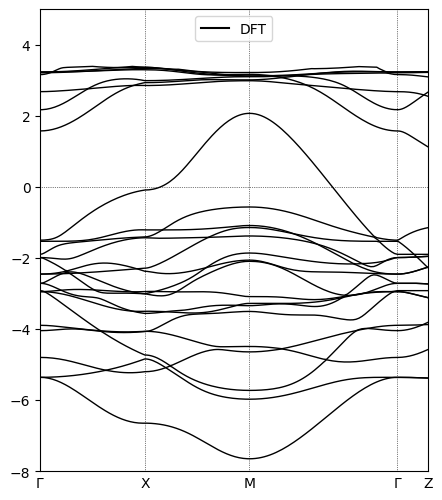

In [3]:
import matplotlib.pyplot as plt
from common import *

# Fermi level (grep Fermi data/scf/lco.scf.out)
eF =  12.7367                                               
# high-symmetry points and labels (from data/bands/lco.bands.out)
high_symm_points = [0.0000, 0.9342, 1.8683, 3.1894, 3.4595] 
high_symm_labels = [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z']

# create matplotlib figure
fig, ax = plt.subplots(figsize=(5,6))

# use kpts and bands from Exercise 1.1
ax.plot_band_structure(kpts, bands, fermi_level=eF, high_symm_points=high_symm_points, high_symm_labels=high_symm_labels)

ax.plot([], [], color='k', label='DFT')
ax.legend(loc='upper center', ncols=2, fontsize=10)
ax.set_ylim(-8, 5)
plt.show()

### 🧪 Excercise 1.3: Overlay the Wannier90 interpolated bands

Let's add the interpolated Wannier90 bands to our DFT band structure to compare. Similar to the DFT band structure, the Wannier90 bands are written to column formatted text file: ``data/mlwf/lco_band.dat``. Load and reformat the data, then use our custom matplotlib function ``plot_bands`` to plot the Wannier90 bands on top of the DFT band structure.

> 💡 **Tip**: Wannier90 uses a different units so you will have to either scale the Wannier90 k-points or the DFT k-points by their ratio so that x-axis wil match.

```python

filename = 'data/mlwf/lco_band.dat'

# Step 1: load the Wannier90 data
w90_data = 
w90_kpts = 
w90_bands = 

# Step 2: calculate scale factor
factor = kpts[-1]/w90_kpts[-1]

# Step 3: add DFT bands from Exercise 1.2
fig, ax = plt.subplots(figsize=(5,6))
ax.plot_band_structure(...)
ax.plot([], [], color='k', label='DFT')

# Step 4: add the Wannier90 bands (and don't forget to subtract the Fermi level!
ax.plot_bands(...)
ax.plot([], [], color='r', label='Wannier90')

ax.legend(loc='upper center', ncols=2, fontsize=10)
ax.set_ylim(-8, 5)
plt.show()
```

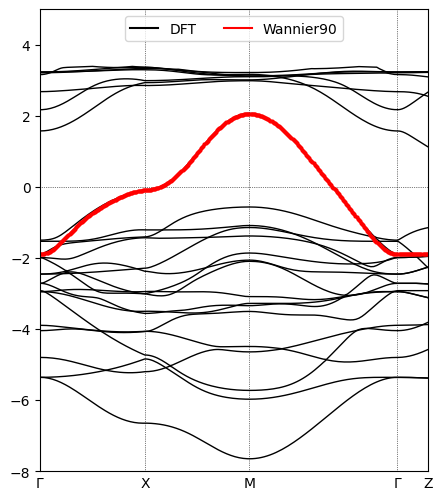

In [4]:
filename = 'data/mlwf/lco_band.dat'

# Step 1: load the Wannier90 data
w90_data = np.loadtxt(filename)
w90_kpts = np.unique(w90_data[:,0])
w90_bands = w90_data[:,1].reshape(-1, len(w90_kpts))

# Step 2: calculate scale factor
factor = kpts[-1]/w90_kpts[-1]

# Step 3: add DFT bands from Exercise 1.2
fig, ax = plt.subplots(figsize=(5,6))
ax.plot_band_structure(kpts, bands, fermi_level=eF, high_symm_points=high_symm_points, high_symm_labels=high_symm_labels)
ax.plot([], [], color='k', label='DFT')

# Step 4: add the Wannier90 bands
ax.plot_bands(w90_kpts*factor, w90_bands-eF, marker='o', ms=2, color='r')
ax.plot([], [], color='r', label='Wannier90')

ax.legend(loc='upper center', ncols=2, fontsize=10)
ax.set_ylim(-8, 5)
plt.show()

## 🔗 2. Connecting to TRIQS

To connect TRIQS to electronic structure codes, we provide a suite of converters that can convert the band structure data into a HDF5-format file that TRIQS can read. Currently, we provide converters for VASP, Wien2k, Elk, and Wannier90. Our Wannier90 converter allows us to connect to any DFT code that also connects to Wannier90.

In this tutorial, we will use the ``Wannier90Converter``. This converter requires the following input file:

```text
0 7 7 7     # k-grid information 0 kx ky ky | -1 indicates to the converter to pick an appropriate k-grid
1.0         # electron density
1           # number of atoms
0 0 2 1 0 0 # atom index, equivalent index, angular quantum number, number of orbitals, (boolean) split into irreps, (boolean) spin-orbit.
```

> ⚠️ **Warning**: This input file will soon be deprecated, so we will not go into too much detail.

With the input file written into ``seedname.inp``, we can run our Wannier90Converter.

```python
from triqs_dft_tools.converters import Wannier90Converter

seedname = "lco"
Wannier90Converter(seedname).convert_dft_input()
```

This will produce for an HDF5 file with name ``seeedname.h5``. This will serve as our input file when writing the DMFT loop.

## 🧠 3. DMFT loop from scratch

In this section, we'll build a single-site DMFT loop for La$_{2}$CuO$_{4}$ using TRIQS/ModEST. We'll proceed in stagess,and **your final task will be write the DMFT self-consistency loop.**

### 🧪 Exercise 3.1: Load one-body elements
We'll start by loading the target electron density and one-body elements (or obe for short) from the hdf5 file we produced in step 2. Load the ``triqs_modest`` module and use the function ``one_body_elements_from_dft_converter``.

> 💡**Tip**: if you want to see the function signature without leaving the notebook to search the API, you write
> 
> ```
> ?name_of_function
> ```
> 
> This will produce for you a Docstring for the ``name_of_function``

```python
import bzsummation as modest

hdf5_filename = 'data/mlwf/lco_wannier.h5'
target_density, obe = 
print(obe)
```

In [4]:
import bzsummation as modest

hdf5_filename = 'data/mlwf/lco_wannier.h5'
target_density, obe = modest.one_body_elements_from_dft_converter(hdf5_filename)
print(obe)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 1
      Represented on a fixed grid of 343 points.
      Shape of H[k_idx, σ, ν, ν'] = [343, 1, 1, 1]
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 1
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   1
             a:   0
        irreps: [1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [343, 1, 1, 1]
  IBZ = false



#### 🔎 Explanation of the OBE

We are studying La$_{2}$CuO$_{4}$ approximated as a single-band system meaning that the low-energy degrees of freedom have been reduced to a single correlated Wannier orbital, the Cu-$d_{x^{2}-y^{2}}$ orbital.

The one-body elements (OBE) class contains four pieces:

##### 🔹 H: Band dispersion $\varepsilon^{\sigma}(k)$
This is the non-interacting (Kohn-Sham) Hamiltonian in Bloch space. $\varepsilon^{\sigma}(k)$ is the **band energy** for spin ($\sigma$) at $k$.

##### 🔹 C_space: Local (correlated) orbital space
This describes the **correlated subspace** $\mathcal{C}$ -- the one that will be used in the DMFT impurity model. It appropriately reflects that we are studying: 1 correlated atom with a single-correlated orbital.

##### 🔹 P: the downfolding projector
For our case, the downfolding projector is trivial identiy matrix. However, when working with different DFT codes or performing a charge self-consistent DFT+DMFT calculation, the projectors become $k$-dependent.

##### 🔹 IBZ: irreducible Brillouin zone symmetrizer
This indicates that the grid of $k$-points spans the **full Brillouin zone**, not just the irreducible wedge (which requires additional symmetry operations to reconstruct the full observable when performing a $k$-summation).

### 🧪 Exercise 3.2: Embedding Description
Create an embedding description from the local space defined in ``obe.C_space``. A central object in TRIQS/ModEST is the ``Embedding`` class, which describes how to map impurity self-energies back to be embedded back to the lattice. For our simple problem, this is trivial, but for more complicated embedding scenarios this can become quite involved (see tutorial XX). To create an embedding, you can use the function ``make_default_embedding``.

```python
E = 
print(E)
```

In [5]:
E = modest.make_default_embedding(obe.C_space)
print(E)

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1
        α:   0

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  



#### 🔎 Explanation of Embedding

In DMFT, the **embedding** tells you how the _correlated subspace_ (from the DFT/Wannier model) is mapped to one or more **impurity problems**. Thus, it is essential to be able to flexibly construct impurity model(s) for your correlated subspace and ensure the correct assignment of local orbitals and spin channesl. Below is a detailed breakdown of the printout from the ``Embedding`` object.

##### 🔹 spin index ($\sigma/\tau$) names: ["up", "down"]
These are the names of the block-diagonal spin indices $\sigma$ in the lattice model. They correspond to the spin-up and spin-down electrons and will be used to construct the fermionic creation and annihilation operators for the impurity model.

We distinguish between:

- $\sigma$: the spin index in the **embedded lattice problem**, and
- $\tau$: the internal spin index used by the **impurity solver** (e.g., in the impurity solver Green's function blocks).

This distinction allows us to support more generic embeddings.

##### 🔹  $\Sigma$_embed block decomposition
This section describes the **block structure** of the embedded self-energy $\Sigma_{\text{embed}}^{\sigma}(\omega)$. In our case, 

- ``dim_α = 1``: There is only **one embedding block** (denoted by index $\alpha= 0$) corresponding to one correlated orbital.
- This is a **single-orbital** DMFT problem, so the self-energy is scalar valued for each spin.

##### 🔹  Impurities
This describes the structure of the **impurity problems** constructed from the local space:

- ``n_imp = 0``: There is one impurity solver (index 0).
- For this impurity solver: there is one correlated orbital with dimension 1 (``dim_γ``).
- The impurity Green's function will therefore have **two blocks**: one for spin-up and one for spin-down.

The solver's block structure (``gf_struct``) is printed:
```
[imp_idx = 0] up_0 [1], down_0 [1]
```
This means:
- The impurity solver has **two blocks**, one for each spin, and
- Each block is of dimension 1.

##### 🔹 Mapping ψ(α,σ) = (imp_idx, γ, τ) 
This table gives the **mappping from the embedded lattice indices** ``(α,σ)`` to the **impurity solver indices** ``(imp_idx, γ, τ)``.

This means:
- The single correlated orbital in the system is mapped to impurity problem 0.
- The spin-up block maps to the spin-up block of the impurity solver.
- The spin-down block maps to the spin-down block of the impurity solver.

### 🧪 Exercise 3.3: Chemical Potential and Local Green's function
Let's use a root finder scheme to find the chemical potential and subsequently compute the local non-interacting Green's function. You will use the functions ``find_chemical_potential`` and ``gloc``.

In order to complete this exercise, you will need to define a mesh. We will work at finite-temparature in the imaginary time formalism, so we will compute the local Green's function on the Matsubara axis with inverse temperature $\beta$ = 10 1/eV.

```python
from triqs.gf import MeshImFreq

beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

# Step 1: find the chemical potential for target density
mu = 

# Step 2: use this chemical potential to compute the local Green's function.
gloc_C = 
print(gloc_C)
```

In [6]:
from triqs.gf import MeshImFreq

beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

# Step 1: find the chemical potential for target density
mu = modest.find_chemical_potential(target_density, obe, beta, verbosity=True) # verbosity broken!

# Step 2: use this chemical potential to compute the local Green's function.
gloc_C = modest.gloc(mesh, obe, mu)
print(gloc_C)

Green's Function  composed of 2 2-index blocks: 
 Greens Function ('0', 'up') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function ('0', 'down') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 3.4: Extract the Local Green's function for the impurity solver(s)
The function ``gloc`` returns the local Green's function in the full correlated subspace. In general, this object is of dimension $ M\times M$. To connect to the impurity solver, we would like to view this Green's function in the space of impurity model(s). This is where the ``Embedding`` class comes in. The class contains two methods: ``extract`` and ``embed``.

- ``extract``: maps a Green's function (or array) from the full correlated space to the space of each impurity solver.
- ``embed``: (reverse of extract) maps a list of Green's functions (or arrays) and embeds these impurities into the bigger correlated space according to the mapping described in the ``Embedding``.

Thus, to prepare the Green's function for the impurity solver, we will use the ``extract`` method from the ``Embedding`` class. In general, the extract function will return a list of objects where the length corresponds to the number of impurity problems defined in the embedding description. Because we are working with a single impurity, we will always grab the first element from this list.

> 💡 **Note**: for a more complicated multi-site, multi-orbital DMFT problem, it is often convenient to loop over these lists.

In [7]:
Gloc = E.extract(gloc_C)[0]
print(Gloc)

Green Function G composed of 2 blocks: 
 Greens Function G_up_0 with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function G_down_0 with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 3.5: Impurity Levels and Hybridization function

The main central inputs to the impurity solver are the impurity levels ($\varepsilon_{d}$) and the hybridization function ($\Delta$). In this excercise, you will calculate the impurity levels and the hybridization function. 

The impurity levels correspond to:

$$ [\varepsilon_{d}]_{m m'} = \sum_{k} P_{m\nu}(k) H_{\nu\nu'}(k) P^{\dagger}_{m'\nu'},$$
where $\mu$ is the chemical potential. We can compute the impurity levels with the function ``impurity_levels`` which takes as an argument the ``obe``.

> 💡 **Tip**: The function ``impurity_levels`` returns the local impurity levels in the full correlated space. In a similar fashion to the local Green's function, you can use ``Embedding``'s ``extract`` function to obtain the impurity levels for each impurity problem.

The hybridization function is defined as:

$$ \Delta(\omega) = \omega + \mu - \varepsilon_{d} - \mathcal{G}_{0}^{-1}(\omega), $$

where $\mathcal{G}_{0} = ((G_{\text{loc}})^{-1} + \Sigma)^{-1}$. The hybridization function can be computed using the function ``extract_delta``.

```python
# Step 1: impurity levels in the C space
hloc0_C = 

# Step 2: extract the local levels into the impurity space
hloc0 = 

# Step 3: compute Δ using hloc0 and Gloc
Delta_iw = 
```

In [8]:
# Step 1: impurity levels in the C space
hloc0_C = modest.impurity_levels(obe) - mu

# Step 2: extract the local levels into the impurity space
hloc0 = E.extract(hloc0_C)[0]

# Step 3: compute Δ using mu, hloc0 and Gloc
Delta_iw = modest.extract_delta(hloc0, Gloc)

### 🧪 Exercise 3.6: Define the interaction
We need to define the interaction Hamiltonian for our impurity model. For our model, this is:

$$ H_{\text{int}} = U n^{\uparrow} n^{\downarrow}.$$

Use the many-body operators within the TRIQS library to write this interaction. Let's take $U$ = 3 eV.

> 💡 **Tip**: The many-body operators must match between all of your Green's functions. You can always get the operator names from the member ``imp_gf_structs`` from the ``Embedding`` class. For our example, the operators are ``c('up_0',0)`` and ``c('down_0', 0)``.

```python
from triqs.operators import n

U = 3.0
h_int = 
```

In [9]:
from triqs.operators import n

U = 3.6
h_int = U*n('up_0',0)*n('down_0',0)

### ▶️ Run the CT-HYB impurity solver

In [10]:
solver_params = dict(length_cycle=60, n_cycles = int(2e+6), 
                          n_warmup_cycles = int(1e+4),
                          perform_tail_fit=True, fit_min_w=6, fit_max_w=10,
                          imag_threshold = 1e-6)
results = solve(Delta_iw, hloc0, h_int, **solver_params)

Root finder search of Chemical Potential to obtain Total Density = 1 +/- 1e-05
x=0.5, f(x)= 5.25856294431212e-47
x=1, f(x)= 7.804399389051097e-45
x=1.5, f(x)= 1.1582755682272908e-42
x=2, f(x)= 1.7190333619194357e-40
x=2.5, f(x)= 2.5512717184518787e-38
x=3, f(x)= 3.7864229546450085e-36
x=3.5, f(x)= 5.619549923973799e-34
x=4, f(x)= 8.340151569515947e-32
x=4.5, f(x)= 1.2377882418261722e-29
x=5, f(x)= 1.837040632694462e-27
x=5.5, f(x)= 2.726410036979813e-25
x=6, f(x)= 4.046351265971475e-23
x=6.5, f(x)= 6.0053177422153494e-21
x=7, f(x)= 8.912681775369343e-19
x=7.5, f(x)= 1.3227592583585248e-16
x=8, f(x)= 1.963148802650765e-14
x=8.5, f(x)= 2.9135711556949514e-12
x=9, f(x)= 4.3241229500523946e-10
x=9.5, f(x)= 6.417557602297381e-08
x=10, f(x)= 9.522326167591098e-06
x=10.5, f(x)= 0.001366948154980121
x=11, f(x)= 0.03569944709537811
x=11.5, f(x)= 0.1374472842572524
x=12, f(x)= 0.3240255107869281
x=12.5, f(x)= 0.6164106608742425
x=13, f(x)= 1.2109291198954333
0 < Chemical Potential < 13
3.5431918

410129966e-49 < Total Density < 1.2109291198954333
10.735558164727744 < Chemical Potential < 13
0.010970122668893021 < Total Density < 1.2109291198954333
12.601955796429431 < Chemical Potential < 13
0.7467574408833251 < Total Density < 1.2109291198954333
12.601955796429431 < Chemical Potential < 12.81912055962288
0.7467574408833251 < Total Density < 1.0241705368126055
12.601955796429431 < Chemical Potential < 12.800199358784884
0.7467574408833251 < Total Density < 1.0032919012441288
12.601955796429431 < Chemical Potential < 12.79765545794349
0.7467574408833251 < Total Density < 1.0004520461012543
12.601955796429431 < Chemical Potential < 12.797306750217016
0.7467574408833251 < Total Density < 1.0000620905368693
12.601955796429431 < Chemical Potential < 12.797258865404736
0.7467574408833251 < Total Density < 1.0000085285552072
Chemical Potential found in 7 iterations:
Total Density = 1.0000085285552072; Chemical Potential = 12.797258865404736

╔╦╗╦═╗╦╔═╗ ╔═╗  �

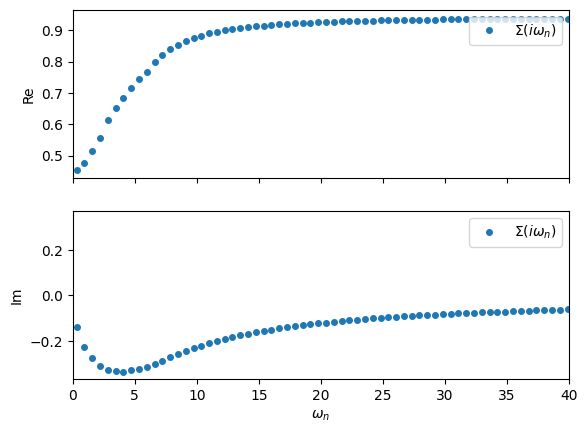

In [14]:
from triqs.plot.mpl_interface import oplot

fig, ax = plt.subplots(2,1, sharex=True)
ax[0].oplot(results.Sigma_iw['up_0'], 'o', ms=4,  mode='R', label=r'$\Sigma(i\omega_{n})$'); ax[0].set_ylabel('Re'); ax[0].set_xlabel('')
ax[1].oplot(results.Sigma_iw['up_0'], 'o', ms=4, mode='I', label=r'$\Sigma(i\omega_{n})$'); ax[1].set_ylabel('Im')
ax[0].set_xlim(0, 40)
plt.show()

In [13]:
print(results)

G_iw        
G_tau       
Sigma_Hartree
Sigma_iw    
Sigma_dynamic
Sigma_moments
auto_corr_time
average_order
average_sign
density_matrix
h_loc_diagonalization
orbital_occupations
performance_analysis
perturbation_order
perturbation_order_total


### 🧪 Exercise 3.7: Write the DMFT update in a loop

You now have all of the pieces to write the DMFT self-consistencey loop. Your task is to fill in the steps that occur during each DMFT iteration, such as solving the impurity problem, updating the self-energy, chemical potential, Green's function, and hybridization function.

#### 🧩 Your Task
Fill in the provided pseudocode to perform the following steps for each DMFT iteration:
1. Solve the impurity problem
2. Embed the self-energy
3. Update the chemical potential
4. Compute the local Green's function
5. Update the hybridization function
   
```python
n_dmft_loops = 15

for n_iter in range(n_dmft_loops):
     print(f"DMFT iteration= {n_iter}")
    
    # TASK 1: Solve the impurity problem and obtain solver_results
    solver_results = 

    # TASK 2: Embed the self-energy from solver_results (E.embed(...))
    Sigma_dynamic_C = 
    Sigma_hartree_C = 

    # TASK 3: Update the chemical potential to match the target density
    mu = 

    # TASK 4: Compute and extract the local Green's function
    Gloc = 

    # TASK 5: update hloc0 with the new chemical potential
    hloc0 = 

    # TASK 6: Update the hybridization function Delta
    Delta_iw = 

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")
```

In [15]:
n_dmft_loops = 20

for n_iter in range(n_dmft_loops):
    print(f"DMFT iteration= {n_iter}")
    
    # solve!
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)
    
    # update Sigma!
    Sigma_dynamic_C  = E.embed([ solver_results.Sigma_dynamic ])
    Sigma_hartree_C  = E.embed([ solver_results.Sigma_Hartree ])

    # update mu!
    mu     = modest.find_chemical_potential(target_density, obe, Sigma_dynamic_C, Sigma_hartree_C, verbosity=False)
    
    # update Gloc!
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_dynamic_C, Sigma_hartree_C))[0]

    # update hloc0 with μ!
    hloc0 = E.extract(modest.impurity_levels(obe) - mu)[0]
    
    # update Δ!
    Delta_iw = modest.extract_delta(hloc0, Gloc, solver_results.Sigma_iw)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

DMFT iteration= 0

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:


0.0983631*c_dag('down_0',0)*c('down_0',0) + 0.0983631*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
13:22:30  16% ETA 00:00:00 cycle 1641 of 10000
13:22:31 100% ETA 00:00:00 cycle 9999 of 10000



Accumulating ...
13:22:31   0% ETA 00:01:39 cycle 2012 of 2000000
13:22:33   2% ETA 00:01:37 cycle 42657 of 2000000
13:22:35   4% ETA 00:01:33 cycle 94944 of 2000000
13:22:39   8% ETA 00:01:29 cycle 160801 of 2000000
13:22:43  11% ETA 00:01:26 cycle 238843 of 2000000
13:22:48  16% ETA 00:01:22 cycle 335602 of 2000000
13:22:54  22% ETA 00:01:16 cycle 458536 of 2000000
13:23:01  30% ETA 00:01:09 cycle 614458 of 2000000
13:23:11  40% ETA 00:00:59 cycle 803792 of 2000000
13:23:23  51% ETA 00:00:48 cycle 1037709 of 2000000
13:23:38  66% ETA 00:00:34 cycle 1328383 of 2000000
13:23:57  84% ETA 00:00:15 cycle 1692677 of 2000000
13:24:13 100% ETA 00:00:0

Execution time: 0.115184 seconds
Execution time: 0.108298 seconds
Execution time: 0.114249 seconds


Δn = |n_lattice - n_impurity| = 0.47716847066705936
DMFT iteration= 1

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-0.471524*c_dag('down_0',0)*c('down_0',0) + -0.471524*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
13:24:19  21% ETA 00:00:00 cycle 2120 of 10000
13:24:19 100% ETA 00:00:00 cycle 9999 of 10000



Accumulating ...
13:24:19   0% ETA 00:01:36 cycle 2064 of 2000000
13:24:21   2% ETA 00:01:36 cycle 43127 of 2000000
13:24:24   4% ETA 00:01:33 cycle 94475 of 2000000
13:24:27   7% ETA 00:01:30 cycle 159315 of 2000000
13:24:31  12% ETA 00:01:25 cycle 240942 of 2000000
13:24:36  17% ETA 00:01:20 cycle 343474 of 2000000
13:24:42  23% ETA 00:01:14 cycle 470675 of 2000000
13:24:50  31% ETA 00:01:06 cycle 628572 of 2000000
13:24:59  41% ETA 00:00:57

Insert error : recovering ... 


...

Execution time: 0.11804 seconds
Execution time: 0.118199 seconds
Execution time: 0.116707 seconds
Execution time: 0.110556 seconds
Execution time: 0.11712 seconds


Δn = |n_lattice - n_impurity| = 0.005489942356180499
DMFT iteration= 14

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.76383*c_dag('down_0',0)*c('down_0',0) + -1.76383*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
13:42:29  28% ETA 00:00:00 cycle 2850 of 10000
13:42:29 100% ETA 00:00:00 cycle 9999 of 10000



Accumulating ...
13:42:29   0% ETA 00:01:10 cycle 2829 of 2000000
13:42:31   3% ETA 00:01:08 cycle 60341 of 2000000
13:42:34   6% ETA 00:01:05 cycle 132424 of 2000000
13:42:37  11% ETA 00:01:02 cycle 222908 of 2000000
13:42:41  16% ETA 00:00:58 cycle 337103 of 2000000
13:42:46  24% ETA 00:00:52 cycle 480027 of 2000000
13:42:52  32% ETA 00:00:46 cycle 657695 of 2000000
13:43:00  43% ETA 00:00:39 cycle 875902 of 2000000
13:43:09  57% ETA 00:00:3

Execution time: 0.115878 seconds
Execution time: 0.113017 seconds


Δn = |n_lattice - n_impurity| = 0.0027489192517984318
DMFT iteration= 18

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.79891*c_dag('down_0',0)*c('down_0',0) + -1.79891*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
13:47:36  28% ETA 00:00:00 cycle 2882 of 10000
13:47:36 100% ETA 00:00:00 cycle 9999 of 10000



Accumulating ...
13:47:36   0% ETA 00:01:08 cycle 2920 of 2000000
13:47:38   3% ETA 00:01:07 cycle 61129 of 2000000
13:47:41   6% ETA 00:01:05 cycle 133320 of 2000000
13:47:44  11% ETA 00:01:02 cycle 223757 of 2000000
13:47:48  16% ETA 00:00:58 cycle 336941 of 2000000
13:47:53  23% ETA 00:00:53 cycle 478618 of 2000000
13:47:59  32% ETA 00:00:47 cycle 653744 of 2000000
13:48:07  43% ETA 00:00:39 cycle 873862 of 2000000
13:48:16  57% ETA 00:00:

Execution time: 0.114917 seconds


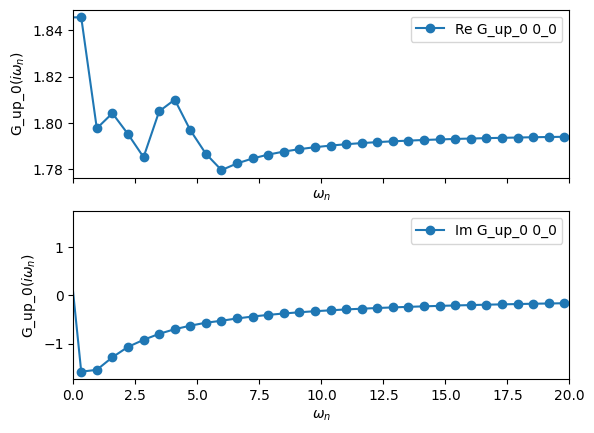

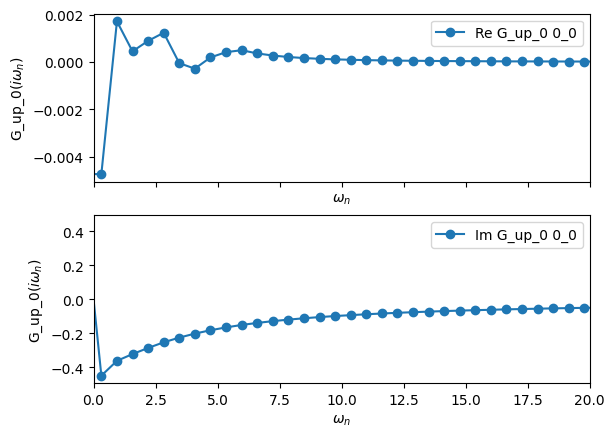

In [16]:
fig, ax = plt.subplots(2,1,sharex=True)
ax[0].oplot(solver_results.Sigma_iw['up_0'], 'o-', mode='R')
ax[1].oplot(solver_results.Sigma_iw['up_0'], 'o-', mode='I')
ax[0].set_xlim(0, 20)

fig, ax = plt.subplots(2,1,sharex=True)
ax[0].oplot(solver_results.G_iw['up_0'], 'o-', mode='R')
ax[1].oplot(solver_results.G_iw['up_0'], 'o-', mode='I')
ax[0].set_xlim(0, 20)
plt.show()

## 🌀 4. Analytic continuation: from Matsubara to real frequencies

In this section, we will learn how to **analytically continue** our results from Matsubara (imaginary) frequencies onto the real-frequency axis, so that we may plot spectral functions. Because analytic continuation is ill-defined, it is wildly unstable and the method of analytic continuation remains an active area of research. However, there are two common analytic continuation techniques: Padé analytic continuation and the maximum entropy (MaxEnt) method. In this section, we will use Padé analytic contintuation since it is simpler. There is an additional tutorial using the MaxEnt method to continue the data.

### The problem
We assume the Matsubra Green's function $G(i\omega_{n})$ corresponds to a dynamic correlation function $G(\omega)$ where $\omega_{n}$ is the Matsubara frequency and $\omega$ is the real frequency. The function $G(z)$ is analytic in the whole upper complex plane of $z$ excluding the real axis, the retarded Green function can be obtained by analytic contintuation $$G(\omega) = G(i\omega_{n}\rightarrow \omega + i0^{+})$$. The spectral function $A(\omega)$ is determined by taking the imaginary part of $G(\omega + i0^{+})$ by the formula

$$ A(\omega) = -\frac{1}{\pi}\mathrm{Im}G(\omega + i0^{+})$$

### Padé method
Padé analytic continuation is based on the assumption that the Matsubara Green function can be approximated by a rational function of degree $r$

$$ G(z) = \frac{\sum_{i=0}^{r-1} p_{i}z^{i}}{\sum_{j=0}^{r-1}q_{j}z^{j} + z^{r}}, $$
where $p_{i}$ and $q_{j}$ are complex. The coefficients can be determined by solving $2r$ linear equatiions from $2r$ arbitrary but different input points ${i\omega_{n}, G(i\omega_{n})}$. Once the coefficients are determined, we replace $z$ with $\omega + i0^{+}$ to obtain the retarded correlation funciton.

### 🧪 Exercise 4.1: Analytically continue the Matsubara Green's function

In this exercise, we will analytically continue the Matsubara Green's function onto the real frequency axis.

#### 🧩 Your task
1. set up a ``BlockGf`` with a real frequency mesh ``MeshReFreq``.
2. For each block in the Matsubara Green's function, use the ``set_from_pade`` method to obtain the real frequency Green's function for this block.
3. Plot the resulting spectral function using the formula $A(\omega) = -\frac{1}{\pi}\text{Im}G(\omega + i0^{+})$.

```python
from triqs.gf import BlockGf, MeshReFreq

n_w = 1000
window = (-10, 10)

# Step 1: set up real-frequency mesh and BlockGf

## get the block shape of the Matsubara Green's function
gf_struct = [ (bl, g.target_shape[0]) for bl, g in solver_results.G_iw ]

## setup real-frequency mesh
mesh = MeshReFreq(window, n_w)

## construct Block Green's function on real-frequency mesh
G_w = BlockGf(mesh, gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 40
freq_offset = 0.0
for block, g in G_w: g.set_from_pade(solver_results.G_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots()
ax.oplot(-(1/np.pi)*G_w['up_0'], mode='I', lw=1, label='')
ax.set_ylabel(r'$A(\omega)$')
plt.show()
```

/Users/harrisonlabollita/software/triqs-build/install/lib/python3.12/site-packages/triqs/plot/mpl_interface.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if is_legend: legend_fct(loc=1)  # legend is built from the label


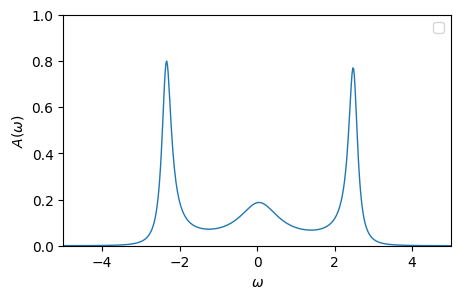

In [17]:
from triqs.gf import BlockGf, MeshReFreq

n_w = 1000
window = (-10, 10)

# Step 1: set up real-frequency mesh and BlockGf

## get the block shape of the Matsubara Green's function
gf_struct = [ (bl, g.target_shape[0]) for bl, g in solver_results.G_iw ]

## setup real-frequency mesh
mesh = MeshReFreq(window, n_w)

## construct Block Green's function on real-frequency mesh
G_w = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 21
freq_offset = 0.0
for block, g in G_w: g.set_from_pade(solver_results.G_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(figsize=(5,3))
ax.oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='')
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 1)
plt.show()

In [18]:
from triqs_maxent import PoormanMaxEnt, LogAlphaMesh, HyperbolicOmegaMesh
tm = PoormanMaxEnt(use_complex=True)
tm.set_G_tau(solver_results.G_tau['up_0'])
tm.alpha_mesh = LogAlphaMesh(alpha_min=1e-6, alpha_max=1e2, n_points=50)
tm.omega = HyperbolicOmegaMesh(omega_min=-10, omega_max=10, n_points=200)
tm.set_error(0.04)
result = tm.run()

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-07-09 15:38:44.239112
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 18.41856888930024
scaling alpha by a factor 2510 (number of data points)
alpha[ 0] =   2.51000000e+05, chi2 =   6.68486754e+03, n_iter=       4 
alpha[ 1] =   1.72348860e+05, chi2 =   6.32865642e+03, n_iter=       3 
alpha[ 2] =   1.18343146e+05, chi2 =   5.84190948e+03, n_iter=       3 
alpha[ 3] =   8.12601843e+04, chi2 =   5.20239642e+03, n_iter=       3 
alpha[ 4] =   5.57972117e+04, chi2 =   4.41370903e+03, n_iter=       4 
alpha[ 5] =   3.83130910e+04, chi2 =   3.52974054e+03, n_iter=       4 
alp

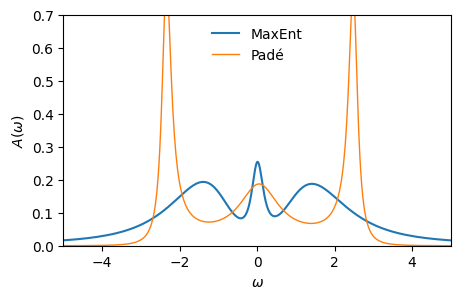

In [19]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(result.omega, result.analyzer_results[0][0][0]['LineFitAnalyzer']['A_out'], label='MaxEnt')
ax.oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='Padé')
ax.set_xlim(-5,5); ax.set_ylim(0, 0.7); ax.legend(frameon=False); ax.set_ylabel(r'$A(\omega)$'); plt.show()

### 🧪 Exercise 4.2: Analytically continue the Matsubara self-energy

In this exercise, we will analytically continue the Matsubara self-energy onto the real-frequency axis. Due to implementation details, you can directly use the same Python code to analytically continue a self-energy as a Green's function in TRIQS. 

> 💡 **Note**: As we saw earlier, the self-energy has a slightly different representation than the Green's function in the fact that it is a constant plus a spectral part.


```python
n_w = 1000
window = (-10, 10)

# Step 1: construct Block Green's function on real-frequency mesh
Sigma_w = BlockGf(mesh, gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 40
freq_offset = 0.0
for block, g in Sigma_w: g.set_from_pade(solver_results.Sigma_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(2,1,sharex=True)
ax[0].oplot(Sigma_w['up_0'], mode='R', lw=1, label='Re')
ax[1].oplot(-Sigma_w['up_0'], mode='I', lw=1, label='-Im')
plt.show()
```

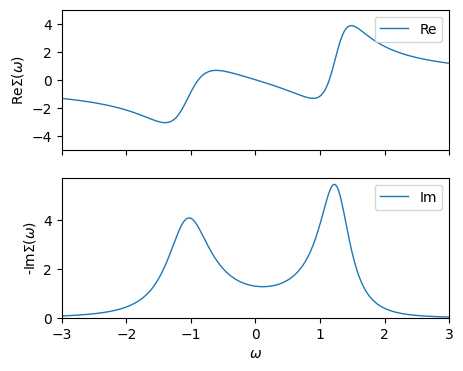

In [58]:
n_w = 1000
window = (-10, 10)

# Step 1: construct Block Green's function on real-frequency mesh
Sigma_w = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 20
freq_offset = 0.0
for block, g in Sigma_w: g.set_from_pade(solver_results.Sigma_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(2,1,sharex=True, figsize=(5,4))
ax[0].oplot(Sigma_w['up_0']-Sigma_w['up_0'][0,0](0.0).real, mode='R', lw=1, label='Re')
ax[1].oplot(-Sigma_w['up_0'], mode='I', lw=1, label='Im')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-3,3); ax[1].set_ylim(0, ); 
ax[0].set_xlabel('')
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.show()

### 🧪 Exercise 4.3: Estimate Z and the scattering rate from the self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as 

$$ Z = 1 - \partial_{\omega}\text{Re}\Sigma(\omega) |_{\omega\rightarrow0}$$.

The scattering rate $\Gamma$ is proportional to $-\mathrm{Im}\Sigma(\omega=0)$. For $Z$, you can fit a linear line to the low-frequency data in the real part of spectrum and use the slope of the line to estimate the derivate.  For the scattering rate, you can fit a polynomial to the low-frequency data in the imaginary part of the self-energy and estimate $-\text{Im}\Sigma(0)$ from this fit.

In [59]:
from triqs.lattice.utils import TB_from_wannier90, k_space_path

In [61]:
tb = TB_from_wannier90(seed='lco', path = './data/mlwf/')

G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments, bz=tb.bz)
ek = tb.dispersion(k_points)

Akw = momentum_resolved_spectral_function(ek, mu, Sigma_w['up_0'])

NameError: name 'ek' is not defined

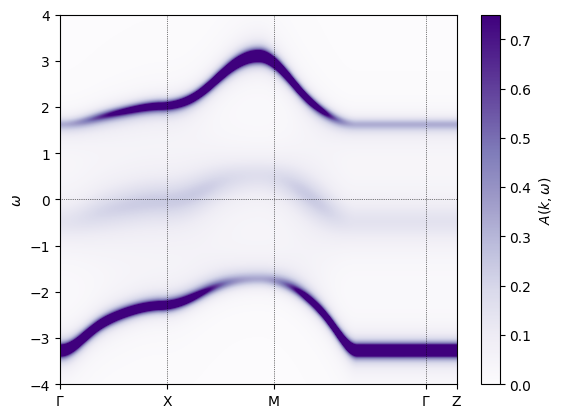